In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!find /content/drive/MyDrive -name "deepfake_detector.ipynb"

/content/drive/MyDrive/Colab Notebooks/deepfake_detector.ipynb


БЛОК 1: Установка библиотек и импорты

In [ ]:
!pip install -q torch torchvision torchmetrics matplotlib seaborn scikit-learn opencv-python

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from PIL import Image
import os
import glob
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve
import warnings
warnings.filterwarnings('ignore')

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.2 MB/s eta 0:00:00
GPU: Tesla T4


БЛОК 2: Монтирование Google Drive и распаковка датасета

In [ ]:

from google.colab import drive
drive.mount('/content/drive')
print("Google Drive подключён!")

ZIP_FILENAME = "data-20260329T180807Z-3-001.zip"

possible_paths = [
    f"/content/drive/MyDrive/dataset/{ZIP_FILENAME}",
    f"/content/drive/MyDrive/{ZIP_FILENAME}",
    f"/content/drive/MyDrive/Colab Notebooks/{ZIP_FILENAME}"
]

ZIP_PATH = None
for path in possible_paths:
    if os.path.exists(path):
        ZIP_PATH = path
        break

if ZIP_PATH and os.path.exists(ZIP_PATH):
    size_mb = os.path.getsize(ZIP_PATH) / 1024 / 1024
    print(f"Найден файл: {ZIP_FILENAME} ({size_mb:.1f} МБ)")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall('/content/data')
    print("Распаковка завершена в /content/data")
else:
    print(f" Файл не найден: {ZIP_FILENAME}")
    os.makedirs('/content/data/train/real', exist_ok=True)
    os.makedirs('/content/data/train/fake', exist_ok=True)
    os.makedirs('/content/data/val/real', exist_ok=True)
    os.makedirs('/content/data/val/fake', exist_ok=True)
    for i in range(200):
        img = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
        Image.fromarray(img).save(f'/content/data/train/real/img_{i}.jpg')
        Image.fromarray(img).save(f'/content/data/train/fake/img_{i}.jpg')
    print("Демо-датасет создан")

Mounted at /content/drive
Google Drive подключён!
Найден файл: data-20260329T180807Z-3-001.zip (481.0 МБ)
Распаковка завершена в /content/data


БЛОК 3: Параметры и трансформации

In [ ]:


IMG_SIZE = 224
BATCH_SIZE = 128
EPOCHS = 30
HIDDEN_SIZE = 256


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.15),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.4),
    transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("    Трансформации настроены")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Эпох: {EPOCHS}")
print(f"   Hidden size: {HIDDEN_SIZE}")

    Трансформации настроены
   Batch size: 128
   Эпох: 30
   Hidden size: 256


БЛОК 4: Загрузка данных

In [ ]:

# Поиск пути к датасету
data_path = '/content/data'

def find_data_path(base='/content/data'):
    for root, dirs, files in os.walk(base):
        if 'real' in dirs and 'fake' in dirs:
            return root
    if os.path.exists('/content/data/train'):
        return '/content/data/train'
    return None

data_path = find_data_path()
if data_path:
    print(f"Датасет найден: {data_path}")
else:
    print("Датасет не найден")
    data_path = '/content/data'

# Загружаем датасет
full_dataset = datasets.ImageFolder(data_path, transform=train_transform)

# Разделение на train/val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Для валидации используем val_transform (без аугментации)
val_subset = torch.utils.data.Subset(
    datasets.ImageFolder(data_path, transform=val_transform),
    val_dataset.indices
)
train_subset = torch.utils.data.Subset(
    datasets.ImageFolder(data_path, transform=train_transform),
    train_dataset.indices
)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\n Статистика датасета:")
print(f"   Всего изображений: {len(full_dataset)}")
print(f"   Train: {len(train_subset)}")
print(f"   Val: {len(val_subset)}")
print(f"   Классы: {full_dataset.classes}")

Датасет найден: /content/data/data/train

 Статистика датасета:
   Всего изображений: 479
   Train: 383
   Val: 96
   Классы: ['fake', 'real']


БЛОК 5: Архитектура модели (усиленный Dropout)

In [ ]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.attention = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, lstm_outputs):
        attn_weights = torch.softmax(self.attention(lstm_outputs), dim=1)
        context_vector = torch.sum(attn_weights * lstm_outputs, dim=1)
        return context_vector, attn_weights


class DeepfakeDetector(nn.Module):
    def __init__(self, hidden_size=256, num_classes=2):
        super(DeepfakeDetector, self).__init__()

        # Загружаем предобученный ResNet18
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # Убираем последние слои (avgpool и fc)
        self.feature_extractor = nn.Sequential(*list(resnet.children())[:-2])

        # LSTM для анализа последовательности признаков
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=False,
            dropout=0.3
        )

        # Механизм внимания
        self.attention = Attention(hidden_size)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        batch, channels, height, width = features.size()
        features = features.view(batch, channels, height * width).permute(0, 2, 1)
        lstm_out, (hidden, cell) = self.lstm(features)
        context_vector, attn_weights = self.attention(lstm_out)
        output = self.classifier(context_vector)

        return output, attn_weights


# Инициализация модели
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DeepfakeDetector(hidden_size=HIDDEN_SIZE, num_classes=2).to(device)

# ЗАМОРАЖИВАЕМ ResNet18
for param in model.feature_extractor.parameters():
    param.requires_grad = False

# Подсчёт параметров
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n Архитектура модели:")
print(f"   Устройство: {device}")
print(f"   Всего параметров: {total_params:,}")
print(f"   Обучаемых параметров: {trainable_params:,}")
print(f"   Заморожено (ResNet18): {total_params - trainable_params:,}")
print(f"   Dropout в классификаторе: 0.6 и 0.4")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]



 Архитектура модели:
   Устройство: cuda
   Всего параметров: 12,064,194
   Обучаемых параметров: 887,682
   Заморожено (ResNet18): 11,176,512
   Dropout в классификаторе: 0.6 и 0.4


БЛОК 6: Loss, Optimizer, Early Stopping

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.002, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_epoch = 0

    def __call__(self, val_loss, epoch):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_epoch = epoch
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print(f"Ранняя остановка на эпохе {epoch+1}")
        else:
            self.best_loss = val_loss
            self.best_epoch = epoch
            self.counter = 0
        return self.early_stop

# Функция потерь с Label Smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Оптимизатор с увеличенным Weight Decay
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001,
    weight_decay=5e-4
)

# Scheduler для уменьшения learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

БЛОК 7: Функции обучения и валидации

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs, _ = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # Градиентное клиппирование
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if batch_idx % 20 == 0 and batch_idx > 0:
            print(f"   Batch {batch_idx}/{len(loader)}: Loss = {loss.item():.4f}")

    return running_loss / len(loader), correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs, _ = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    return running_loss / len(loader), correct / total, all_preds, all_labels, all_probs

print("Функции обучения готовы")

Функции обучения готовы


БЛОК 8: Цикл обучения

In [ ]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0.0
best_epoch = 0

early_stopping = EarlyStopping(patience=5, min_delta=0.002, verbose=True)

for epoch in range(EPOCHS):
    print(f"\nЭпоха {epoch+1}/{EPOCHS}")

    # Обучение
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Валидация
    val_loss, val_acc, val_preds, val_labels, val_probs = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Обновление learning rate
    scheduler.step(val_loss)

    # Сохранение лучшей модели
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(model.state_dict(), '/content/best_model.pth')
        print(f"СОХРАНЕНА лучшая модель с точностью {val_acc:.4f} (эпоха {epoch+1})")

    current_lr = optimizer.param_groups[0]['lr']
    gap = train_acc - val_acc
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"   Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print(f"   Learning Rate: {current_lr:.6f}")
    print(f"   Разрыв Train-Val: {gap:.2%}")

    # Early Stopping проверка
    if early_stopping(val_loss, epoch):
        print(f"\n Ранняя остановка на эпохе {epoch+1}")
        break

print(f"\n Обучение завершено!")
print(f"Лучшая точность на валидации: {best_val_acc:.4f} (эпоха {best_epoch+1})")


Эпоха 1/30
СОХРАНЕНА лучшая модель с точностью 0.6562 (эпоха 1)
   Train Loss: 0.6633 | Train Acc: 0.6057
   Val Loss: 0.6668 | Val Acc: 0.6562
   Learning Rate: 0.001000
   Разрыв Train-Val: -5.05%

Эпоха 2/30
   Train Loss: 0.6353 | Train Acc: 0.6867
   Val Loss: 0.6555 | Val Acc: 0.6562
   Learning Rate: 0.001000
   Разрыв Train-Val: 3.04%

Эпоха 3/30
   Train Loss: 0.6411 | Train Acc: 0.6867
   Val Loss: 0.6425 | Val Acc: 0.6562
   Learning Rate: 0.001000
   Разрыв Train-Val: 3.04%

Эпоха 4/30
   Train Loss: 0.6205 | Train Acc: 0.6893
   Val Loss: 0.6317 | Val Acc: 0.6562
   Learning Rate: 0.001000
   Разрыв Train-Val: 3.30%

Эпоха 5/30
СОХРАНЕНА лучшая модель с точностью 0.6667 (эпоха 5)
   Train Loss: 0.6063 | Train Acc: 0.6867
   Val Loss: 0.6243 | Val Acc: 0.6667
   Learning Rate: 0.001000
   Разрыв Train-Val: 2.00%

Эпоха 6/30
СОХРАНЕНА лучшая модель с точностью 0.6771 (эпоха 6)
   Train Loss: 0.5774 | Train Acc: 0.7076
   Val Loss: 0.6055 | Val Acc: 0.6771
   Learning Rate: 

 БЛОК 9: Загрузка лучшей модели и финальная оценка

In [ ]:
# Загружаем лучшую модель
model.load_state_dict(torch.load('/content/best_model.pth'))
model.eval()

# Финальная валидация
val_loss, val_acc, val_preds, val_labels, val_probs = validate(model, val_loader, criterion, device)



print(f"\n Итоговая точность: {val_acc:.4f} ({val_acc*100:.2f}%)")

# Classification Report
print(f"\n Classification Report:")
print(classification_report(val_labels, val_preds, target_names=full_dataset.classes))

# Детальные метрики
print(f"\n Детальные метрики:")
print(f"   Accuracy:  {accuracy_score(val_labels, val_preds):.4f}")
print(f"   Precision: {precision_score(val_labels, val_preds):.4f}")
print(f"   Recall:    {recall_score(val_labels, val_preds):.4f}")
print(f"   F1-Score:  {f1_score(val_labels, val_preds):.4f}")
print(f"   AUC-ROC:   {roc_auc_score(val_labels, val_probs):.4f}")


 Итоговая точность: 0.7604 (76.04%)

 Classification Report:
              precision    recall  f1-score   support

        fake       0.78      0.42      0.55        33
        real       0.76      0.94      0.84        63

    accuracy                           0.76        96
   macro avg       0.77      0.68      0.69        96
weighted avg       0.76      0.76      0.74        96


 Детальные метрики:
   Accuracy:  0.7604
   Precision: 0.7564
   Recall:    0.9365
   F1-Score:  0.8369
   AUC-ROC:   0.7922


БЛОК 10: Визуализации (графики, матрица, ROC)

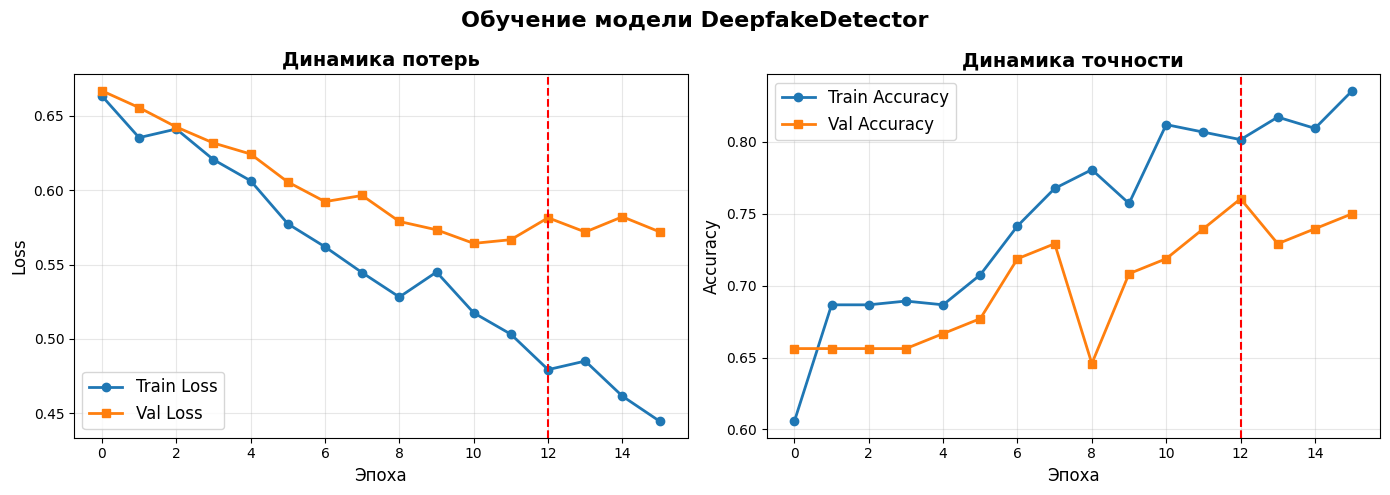

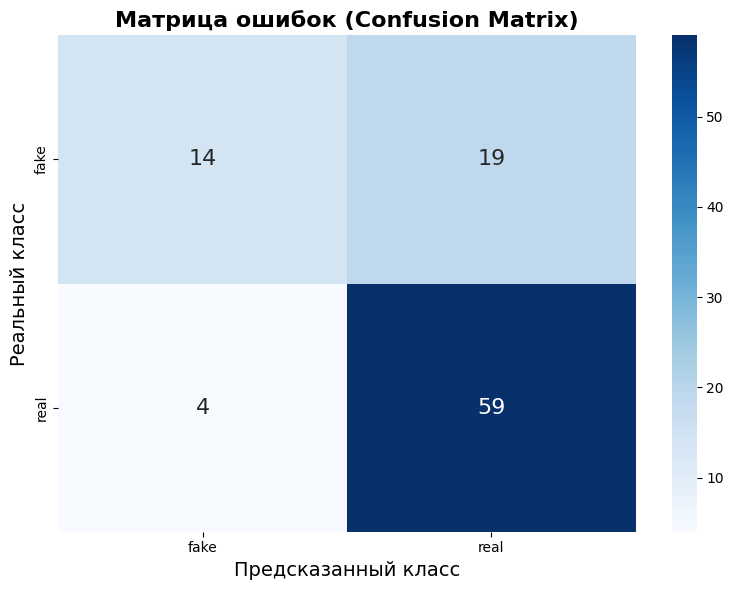

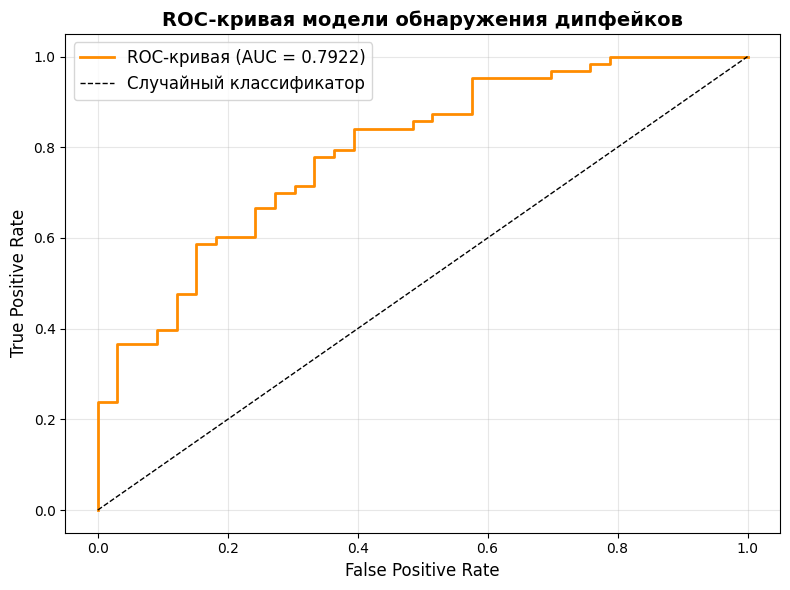

In [ ]:
# Графики обучения
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2, marker='o')
plt.plot(val_losses, label='Val Loss', linewidth=2, marker='s')
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Динамика потерь', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Лучшая модель (эпоха {best_epoch+1})')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy', linewidth=2, marker='o')
plt.plot(val_accs, label='Val Accuracy', linewidth=2, marker='s')
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Динамика точности', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Лучшая модель (эпоха {best_epoch+1})')

plt.suptitle('Обучение модели DeepfakeDetector', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion Matrix
cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes,
            annot_kws={"size": 16})
plt.title('Матрица ошибок (Confusion Matrix)', fontsize=16, fontweight='bold')
plt.ylabel('Реальный класс', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=14)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC-кривая
fpr, tpr, thresholds = roc_curve(val_labels, val_probs)
auc_score = roc_auc_score(val_labels, val_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC-кривая (AUC = {auc_score:.4f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайный классификатор')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривая модели обнаружения дипфейков', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()


БЛОК 11: Grad-CAM визуализация

Загружена лучшая модель


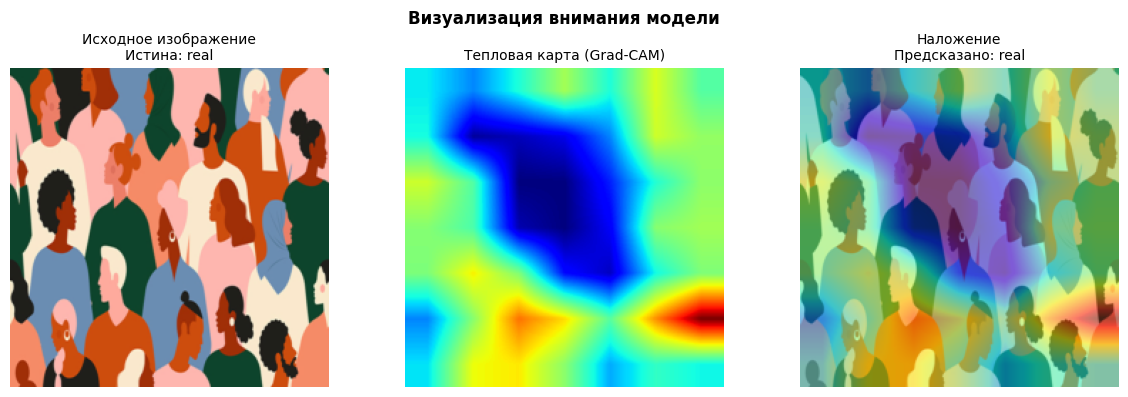

   Grad-CAM для изображения 1 завершён


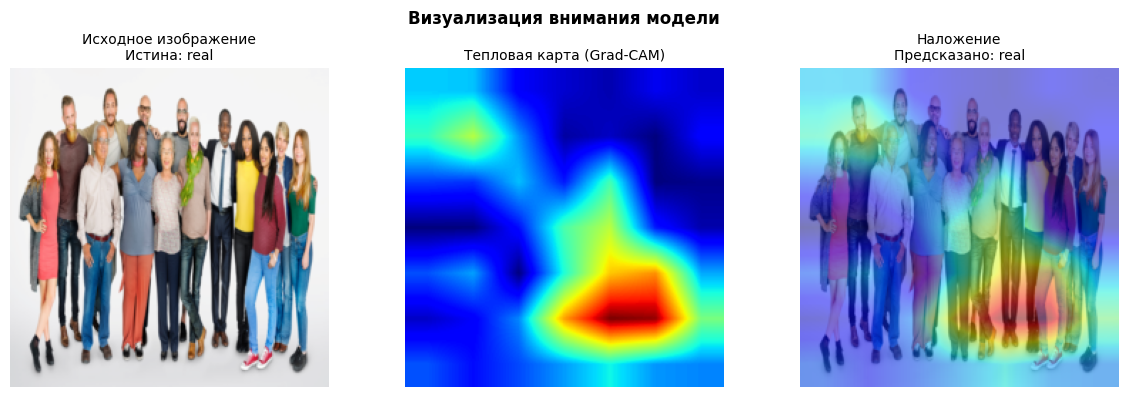

   Grad-CAM для изображения 2 завершён


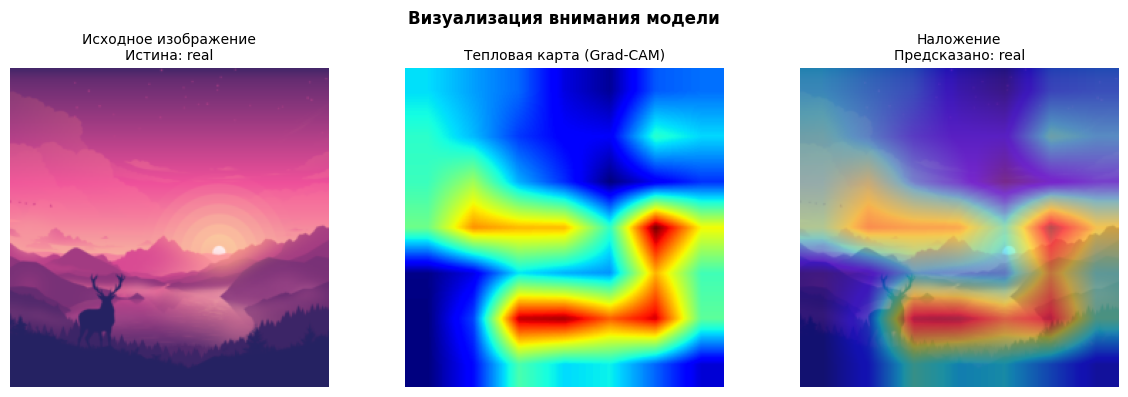

   Grad-CAM для изображения 3 завершён


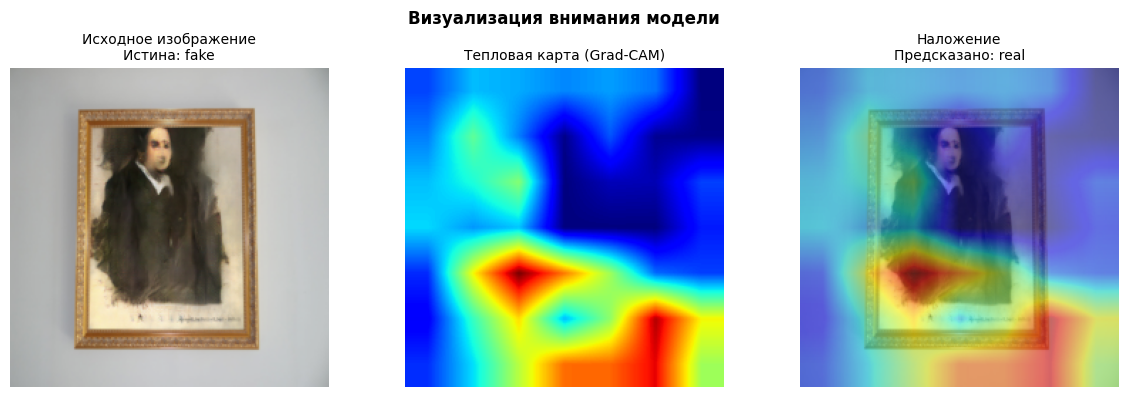

   Grad-CAM для изображения 4 завершён


In [ ]:
def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.numpy().transpose((1, 2, 0))
    img = std * img + mean
    return np.clip(img, 0, 1)

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.handle_forward = target_layer.register_forward_hook(self.save_activation)
        self.handle_backward = target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_heatmap(self, input_tensor, class_idx=None):
        # ВАЖНО: временно переключаем модель в режим train для backward
        self.model.train()

        self.model.zero_grad()
        output, _ = self.model(input_tensor)

        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        one_hot = torch.zeros_like(output)
        one_hot[0][class_idx] = 1
        output.backward(gradient=one_hot, retain_graph=True)

        weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)
        heatmap = torch.sum(weights * self.activations, dim=1).squeeze()
        heatmap = torch.nn.functional.relu(heatmap)

        if torch.max(heatmap) > 0:
            heatmap = heatmap / torch.max(heatmap)

        # Возвращаем модель в исходное состояние eval
        self.model.eval()

        return heatmap.detach().cpu().numpy()

    def remove_hooks(self):
        self.handle_forward.remove()
        self.handle_backward.remove()


# Загружаем лучшую модель
try:
    model.load_state_dict(torch.load('/content/best_model.pth'))
    print("Загружена лучшая модель")
except:
    print("Использую текущую модель")

model.eval()

# Выбираем несколько изображений для анализа
sample_indices = random.sample(range(len(val_subset)), min(4, len(val_subset)))

# Используем последний слой ResNet18 для Grad-CAM
target_layer = model.feature_extractor[-1]

for i, idx in enumerate(sample_indices):
    img_tensor, true_label = val_subset[idx]
    img_input = img_tensor.unsqueeze(0).to(device)
    img_input.requires_grad = True

    # Получаем предсказание
    with torch.no_grad():
        outputs, _ = model(img_input)
        _, pred = torch.max(outputs, 1)

    pred_class = full_dataset.classes[pred.item()]
    true_class = full_dataset.classes[true_label]

    # Grad-CAM (теперь работает!)
    cam = GradCAM(model, target_layer)
    heatmap = cam.generate_heatmap(img_input, class_idx=pred.item())

    # Визуализация
    img_show = denormalize(img_tensor)
    heatmap_resized = cv2.resize(heatmap, (img_show.shape[1], img_show.shape[0]))

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img_show)
    axes[0].set_title(f'Исходное изображение\nИстина: {true_class}', fontsize=10)
    axes[0].axis('off')

    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title(f'Тепловая карта (Grad-CAM)', fontsize=10)
    axes[1].axis('off')

    axes[2].imshow(img_show)
    axes[2].imshow(heatmap_resized, cmap='jet', alpha=0.5)
    axes[2].set_title(f'Наложение\nПредсказано: {pred_class}', fontsize=10)
    axes[2].axis('off')

    plt.suptitle('Визуализация внимания модели', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    cam.remove_hooks()
    print(f"   Grad-CAM для изображения {i+1} завершён")


БЛОК 12: Анализ ошибок

   Всего ошибок: 23 из 96 (24.0%)

 Примеры ошибок:
      1. Индекс 5: Истина: fake → Предсказано: real


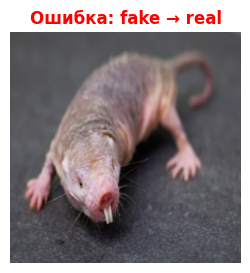

      2. Индекс 6: Истина: fake → Предсказано: real


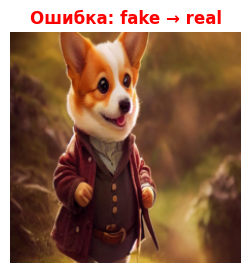

      3. Индекс 24: Истина: fake → Предсказано: real


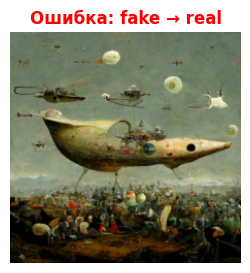

In [ ]:
# Находим ошибочные предсказания
errors = []
for i, (pred, true) in enumerate(zip(val_preds, val_labels)):
    if pred != true:
        errors.append((i, pred, true))

print(f"   Всего ошибок: {len(errors)} из {len(val_labels)} ({len(errors)/len(val_labels)*100:.1f}%)")

if len(errors) > 0:
    print(f"\n Примеры ошибок:")
    for i, (idx, pred, true) in enumerate(errors[:3]):
        true_class = full_dataset.classes[true]
        pred_class = full_dataset.classes[pred]
        print(f"      {i+1}. Индекс {idx}: Истина: {true_class} → Предсказано: {pred_class}")

        # Показываем изображение с ошибкой
        img_tensor, _ = val_subset[idx]
        img_show = denormalize(img_tensor)
        plt.figure(figsize=(3, 3))
        plt.imshow(img_show)
        plt.title(f'Ошибка: {true_class} → {pred_class}', color='red', fontweight='bold')
        plt.axis('off')
        plt.show()

БЛОК 15: АНАЛИЗ 10 ИЗОБРАЖЕНИЙ

In [ ]:
# Установка библиотек для LLM
!pip install -q transformers accelerate

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import cv2
import numpy as np
from scipy.fft import fft2, fftshift

# Загрузка модели Qwen
model_name = 'Qwen/Qwen2.5-1.5B-Instruct'
print(f"\n Загрузка модели {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
llm_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map='auto'
)
print("LLM модель загружена!")


 Загрузка модели Qwen/Qwen2.5-1.5B-Instruct...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

LLM модель загружена!


ФУНКЦИИ ДЛЯ ДЕТЕКЦИИ АРТЕФАКТОВ

In [ ]:

def detect_blur(image_np):
    """Детекция размытия (Laplacian variance)"""
    gray = cv2.cvtColor((image_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    if laplacian_var < 100:
        return "сильное размытие", laplacian_var
    elif laplacian_var < 300:
        return "небольшое размытие", laplacian_var
    else:
        return "четкое изображение", laplacian_var

def detect_noise(image_np):

    gray = cv2.cvtColor((image_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    noise = np.std(gray) / 255
    if noise > 0.15:
        return "высокий уровень шума", noise
    elif noise > 0.08:
        return "средний уровень шума", noise
    else:
        return "низкий уровень шума", noise

def detect_contrast(image_np):

    gray = cv2.cvtColor((image_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    contrast = gray.std() / 255
    if contrast < 0.2:
        return "низкая контрастность", contrast
    elif contrast > 0.5:
        return "высокая контрастность", contrast
    else:
        return "нормальная контрастность", contrast

def detect_frequency_artifacts(image_np):
    """Детекция артефактов в частотной области (FFT)"""
    gray = cv2.cvtColor((image_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    f = fft2(gray)
    fshift = fftshift(f)
    magnitude_spectrum = np.log(np.abs(fshift) + 1)
    # Проверка на периодические артефакты
    mean_spectrum = np.mean(magnitude_spectrum)
    if mean_spectrum > 8:
        return "возможны периодические артефакты", mean_spectrum
    else:
        return "нормальный частотный спектр", mean_spectrum

def detect_symmetry(image_np):
    """Детекция неестественной симметрии (признак дипфейка)"""
    h, w = image_np.shape[:2]
    left = image_np[:, :w//2]
    right = np.fliplr(image_np[:, w//2:])
    if left.shape[1] != right.shape[1]:
        min_w = min(left.shape[1], right.shape[1])
        left = left[:, :min_w]
        right = right[:, :min_w]
    symmetry_score = np.mean((left - right) ** 2)
    if symmetry_score < 0.01:
        return "подозрительно высокая симметрия (артефакт)", symmetry_score
    else:
        return "естественная асимметрия", symmetry_score

def analyze_image_artifacts(img_tensor):
    # Денормализация
    img_np = denormalize(img_tensor)

    artifacts = {}

    # Все анализы
    artifacts['blur'] = detect_blur(img_np)
    artifacts['noise'] = detect_noise(img_np)
    artifacts['contrast'] = detect_contrast(img_np)
    artifacts['frequency'] = detect_frequency_artifacts(img_np)
    artifacts['symmetry'] = detect_symmetry(img_np)

    return artifacts, img_np

ОТБОР НАИБОЛЕЕ ИНТЕРЕСНЫХ ИЗОБРАЖЕНИЙ

In [ ]:
def select_diverse_samples(val_subset, model, device, num_samples=10):
    """Выбирает разнообразные примеры (уверенные, неуверенные, ошибки)"""
    model.eval()

    results = []
    for idx in range(len(val_subset)):
        img_tensor, true_label = val_subset[idx]
        img_input = img_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            outputs, _ = model(img_input)
            probs = torch.softmax(outputs, dim=1)
            confidence, pred = torch.max(probs, 1)

        results.append({
            'idx': idx,
            'true_label': true_label,
            'pred_label': pred.item(),
            'confidence': confidence.item(),
            'is_correct': pred.item() == true_label
        })

    # Разделяем на категории
    correct_high_conf = [r for r in results if r['is_correct'] and r['confidence'] > 0.9]
    correct_med_conf = [r for r in results if r['is_correct'] and 0.6 < r['confidence'] <= 0.9]
    errors = [r for r in results if not r['is_correct']]

    # Выбираем разнообразные примеры
    selected = []
    selected.extend(random.sample(correct_high_conf, min(3, len(correct_high_conf))))
    selected.extend(random.sample(correct_med_conf, min(3, len(correct_med_conf))))
    selected.extend(random.sample(errors, min(4, len(errors))))

    # Если не хватает, добираем случайными
    while len(selected) < num_samples:
        remaining = [r for r in results if r not in selected]
        if remaining:
            selected.append(random.choice(remaining))
        else:
            break

    return selected[:num_samples]

ГЕНЕРАЦИЯ ТОЧНОГО ОПИСАНИЯ

In [ ]:
def generate_detailed_description(img_tensor, true_label, pred_label, confidence, artifacts):
    """Генерирует точное описание на основе детекции артефактов"""

    true_class = full_dataset.classes[true_label]
    pred_class = full_dataset.classes[pred_label]

    # Формируем список обнаруженных артефактов
    detected_issues = []

    if artifacts['blur'][1] < 200:
        detected_issues.append(f"- {artifacts['blur'][0]} (показатель размытия: {artifacts['blur'][1]:.1f})")

    if artifacts['contrast'][1] < 0.25 or artifacts['contrast'][1] > 0.55:
        detected_issues.append(f"- {artifacts['contrast'][0]} (контраст: {artifacts['contrast'][1]:.2f})")

    if artifacts['noise'][1] > 0.12:
        detected_issues.append(f"- {artifacts['noise'][0]} (уровень шума: {artifacts['noise'][1]:.3f})")

    if artifacts['symmetry'][1] < 0.008:
        detected_issues.append(f"- {artifacts['symmetry'][0]} (оценка симметрии: {artifacts['symmetry'][1]:.4f})")

    # Формируем промпт с конкретными данными
    if pred_class == true_class:
        if true_class == 'fake':
            issues_text = "\n".join(detected_issues) if detected_issues else "- микроартефакты в высокочастотной области"
            prompt = f"""Сгенерируй описание для отчета криминалиста.

На данном изображении обнаружены следующие артефакты:
{issues_text}

Напиши 2-3 предложения, начиная со слов «На данном изображении мы видим...».
Укажи конкретные признаки дипфейка из списка выше. Будь технически точен."""
        else:  # real
            prompt = f"""Сгенерируй описание для отчета криминалиста.

Анализ показал:
- {artifacts['blur'][0]} (размытие: {artifacts['blur'][1]:.1f})
- {artifacts['contrast'][0]} (контраст: {artifacts['contrast'][1]:.2f})
- {artifacts['noise'][0]} (шум: {artifacts['noise'][1]:.3f})

Напиши 2-3 предложения, начиная со слов «На данном изображении мы видим...».
Подтверди, что изображение выглядит естественно, текстуры кожи нормальные."""
    else:  # ошибка
        prompt = f"""Сгенерируй описание для отчета криминалиста.

Модель ошиблась: Истина = {true_class.upper()}, Предсказание = {pred_class.upper()}
Уверенность: {confidence:.1f}%

Анализ изображения:
- {artifacts['blur'][0]}
- {artifacts['contrast'][0]}
- {artifacts['noise'][0]}

Напиши 2-3 предложения, начиная со слов «На данном изображении мы видим...».
Объясни, почему этот случай сложный для классификации."""

    # Генерация через LLM
    messages = [
        {'role': 'system', 'content': 'Ты — эксперт-криминалист по дипфейкам. Пиши технически точно, опираясь на предоставленные данные.'},
        {'role': 'user', 'content': prompt}
    ]

    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = tokenizer([text], return_tensors='pt').to(llm_model.device)

    generated_ids = llm_model.generate(
        model_inputs.input_ids,
        max_new_tokens=200,
        temperature=0.3,
        top_p=0.9,
        do_sample=True
    )

    generated_ids = [output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)]
    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return response

ОСНОВНОЙ ЦИКЛ АНАЛИЗА

In [ ]:

selected_samples = select_diverse_samples(val_subset, model, device, num_samples=10)


descriptions = []

for i, sample in enumerate(selected_samples):
    idx = sample['idx']
    true_label = sample['true_label']
    pred_label = sample['pred_label']
    confidence = sample['confidence']
    true_class = full_dataset.classes[true_label]
    pred_class = full_dataset.classes[pred_label]
    is_correct = sample['is_correct']

    # Получаем изображение
    img_tensor, _ = val_subset[idx]

    # Анализ артефактов
    artifacts, img_np = analyze_image_artifacts(img_tensor)

    # Визуализация
    plt.figure(figsize=(5, 5))
    plt.imshow(img_np)

    plt.title(f'{status}\nИстина: {true_class.upper()} | Модель: {pred_class.upper()} ({confidence*100:.1f}%)',
              color=color, fontweight='bold')
    plt.axis('off')
    plt.show()

    # Вывод детекции артефактов
    print(f"\nДетекция артефактов (фото {i+1}):")
    print(f"   Размытие: {artifacts['blur'][0]} ({artifacts['blur'][1]:.1f})")
    print(f"   Контраст: {artifacts['contrast'][0]} ({artifacts['contrast'][1]:.2f})")
    print(f"   Шум: {artifacts['noise'][0]} ({artifacts['noise'][1]:.3f})")
    print(f"   Симметрия: {artifacts['symmetry'][0]} ({artifacts['symmetry'][1]:.4f})")
    print(f"   Частотный спектр: {artifacts['frequency'][0]}")

    # Генерация описания
    description = generate_detailed_description(img_tensor, true_label, pred_label, confidence, artifacts)

    print(f"\nОписание (фото {i+1}):")
    print(description)


    descriptions.append({
        'index': i+1,
        'true_class': true_class,
        'pred_class': pred_class,
        'confidence': confidence * 100,
        'is_correct': is_correct,
        'artifacts': {
            'blur': artifacts['blur'][0],
            'contrast': artifacts['contrast'][0],
            'noise': artifacts['noise'][0],
            'symmetry': artifacts['symmetry'][0]
        },
        'description': description
    })

Output hidden; open in https://colab.research.google.com to view.

In [1]:
!pwd
!ls -la

/content
total 16
drwxr-xr-x 1 root root 4096 Sep  4 13:32 .
drwxr-xr-x 1 root root 4096 Sep 21 16:25 ..
drwxr-xr-x 4 root root 4096 Sep  4 13:32 .config
drwxr-xr-x 1 root root 4096 Sep  4 13:32 sample_data
